In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
#knihovny

In [11]:
np.random.seed(23) #to have every time the same random points
x,y = make_blobs(n_samples=100,n_features=2, centers=4)

scaler = StandardScaler()
scaler.fit(x)
x = scaler.transform(x) #prevod, because using euclidean space

k=4
centers = np.random.uniform(-2,2, size =(k, x.shape[1]))
#creating random centers


In [12]:
def distance(a,b):
    return np.sqrt(np.sum((a-b)**2))

#creating euclidean distance

In [18]:
def assign_clusters(x, clusters):
    for c in clusters:
        clusters[c] ['points'] = []

    for idx in range(x.shape[0]):
        curr_x = x[idx]

        dist = [distance(curr_x, clusters[i]['center'])for i in clusters ]

        curr_cluster = np.argmin(dist)

        clusters[curr_cluster]['points'].append(curr_x)

    return clusters

In [19]:
def update_clusters(clusters):
    for i in clusters:
        points = np.array(clusters[i]['points'])

        if points.shape[0] > 0:
            clusters[i]['center'] = points.mean(axis=0)

    return clusters

In [20]:
k = 4
centers = np.random.uniform(-2, 2, size=(k, x.shape[1]))

# building cluster dictionary
clusters = {i: {'center': centers[i], 'points': []} for i in range(k)}

# saveing initial centers
initial_centers = centers.copy()

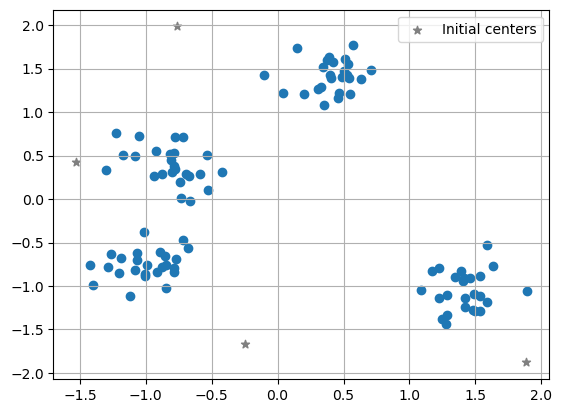

In [25]:
#plotting random clusters with intialized centers
plt.scatter(x[:,0],x[:,1])
plt.grid(True)
plt.scatter(initial_centers[:,0], initial_centers[:,1], 
            color='gray', marker='*', label='Initial centers')

plt.legend()
plt.show()

In [26]:
#iteration
for _ in range(100):
    old_centers = np.array([clusters[i]['center'] for i in clusters])

    clusters = assign_clusters(x, clusters)
    clusters = update_clusters(clusters)

    new_centers = np.array([clusters[i]['center'] for i in clusters])

    # stop if centers do not move
    if np.allclose(old_centers, new_centers):
        break

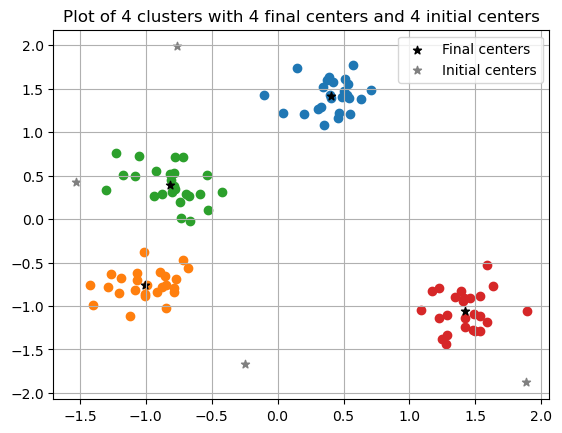

In [27]:
final_centers = np.array([clusters[i]['center'] for i in clusters])

for i in range(k):
    pts = np.array(clusters[i]['points'])
    if pts.shape[0] == 0:
        continue
    plt.scatter(pts[:,0], pts[:,1])

# plotting final centers
plt.scatter(final_centers[:,0], final_centers[:,1],color='black', marker='*', label='Final centers')

# plotting initial centers
plt.scatter(initial_centers[:,0],initial_centers[:,1],color='gray', marker='*',label='Initial centers')

plt.legend()
plt.title('Plot of 4 clusters with 4 final centers and 4 initial centers')
plt.grid(True)
plt.show()